In [1]:
# ============================================================
# MASTER IN FINANZA QUANTITATIVA - PROGETTO VALUTAZIONE DERIVATI
# Esercizio Prof. Marco Airoldi
# Confronto tra modelli Heston, Merton e Local Volatility
# ============================================================

# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import scipy.stats as si
import scipy.optimize as opt
from scipy.interpolate import RectBivariateSpline, interp1d 
import math
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
from IPython.display import display

# Per risultati riproducibili
np.random.seed(42)

In [2]:
# ============================================================
# PARAMETRI DI MERCATO E SUPERFICIE DI VOLATILITÀ
# ============================================================

S0 = 100
r = 0.02
q = 0.0

# 4 maturities
maturities = np.array([0.25, 0.5, 1.0, 2.0])
k_grid = np.linspace(-0.3, 0.3, 12)

print("=" * 60)
print("COSTRUZIONE SUPERFICIE DI MERCATO")
print("=" * 60)
print(f"S0 = {S0}, r = {r}, q = {q}")
print(f"Maturità: {maturities}")
print(f"Log-moneyness: da {k_grid[0]:.2f} a {k_grid[-1]:.2f}")

COSTRUZIONE SUPERFICIE DI MERCATO
S0 = 100, r = 0.02, q = 0.0
Maturità: [0.25 0.5  1.   2.  ]
Log-moneyness: da -0.30 a 0.30


In [3]:
# ============================================================
# SUPERFICIE DI VOLATILITÀ IMPLICITA SINTETICA
# ============================================================

def implied_vol_surface(T, k):
    """
    Superficie di volatilità parametrica con:
    - Skew negativo (termine -0.25*exp(-T)*k)
    - Ala destra quasi piatta (termine quadratico piccolo)
    - Termine di struttura per scadenza (+0.02*T)
    - Livello base 18%
    """
    return 0.18 + 0.02*T - 0.25*np.exp(-T)*k + 0.35*np.exp(-0.5*T)*k**2

# Calcola la superficie completa
vol_surface = np.array([[implied_vol_surface(T, k) for k in k_grid] for T in maturities])

print("\nSuperficie di volatilità creata (valori ATM per ogni scadenza):")
for i, T in enumerate(maturities):
    atm_idx = len(k_grid) // 2
    print(f"T={T}Y: vol ATM = {vol_surface[i, atm_idx]:.4f}")


Superficie di volatilità creata (valori ATM per ogni scadenza):
T=0.25Y: vol ATM = 0.1799
T=0.5Y: vol ATM = 0.1861
T=1.0Y: vol ATM = 0.1976
T=2.0Y: vol ATM = 0.2192


In [4]:
# ============================================================
# PREZZI DI MERCATO CON BLACK-SCHOLES
# ============================================================

def bs_call_price(S, K, T, r, q, sigma):
    """Prezzo call europea con Black-Scholes"""
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*np.exp(-q*T)*si.norm.cdf(d1) - K*np.exp(-r*T)*si.norm.cdf(d2)

def bs_put_price(S, K, T, r, q, sigma):
    """Prezzo put europea con Black-Scholes (put-call parity)"""
    call = bs_call_price(S, K, T, r, q, sigma)
    return call - S*np.exp(-q*T) + K*np.exp(-r*T)

# Calcola i prezzi di mercato per tutte le opzioni
market_prices = np.array([[bs_call_price(S0, S0*np.exp(k), T, r, q, vol_surface[i, j])
                           for j, k in enumerate(k_grid)]
                          for i, T in enumerate(maturities)])

print(f"\nPrezzi di mercato calcolati per {len(maturities)} scadenze × {len(k_grid)} strike")

# Griglia ridotta per calibrazione (5 strike)
calib_indices = np.linspace(0, len(k_grid)-1, 5, dtype=int)
k_calib = k_grid[calib_indices]
market_prices_calib = market_prices[:, calib_indices]

print(f"Strike per calibrazione: {len(k_calib)} (ridotti per efficienza)")


Prezzi di mercato calcolati per 4 scadenze × 12 strike
Strike per calibrazione: 5 (ridotti per efficienza)


In [5]:
# ============================================================
# FUNZIONI UTILI (IMPLIED VOL INVERSION)
# ============================================================

def implied_vol_from_price(price, S, K, T, r, q):
    """
    Calcola la volatilità implicita da un prezzo di mercato
    Usa il metodo di brentq per trovare la radice
    """
    if price <= 0 or price >= S:
        return np.nan

    def f(sigma):
        return bs_call_price(S, K, T, r, q, sigma) - price

    try:
        return opt.brentq(f, 1e-6, 3.0)
    except (ValueError, RuntimeError):
        return np.nan

def build_implied_surface(price_surface):
    """Costruisce una superficie di volatilità implicita da una superficie di prezzi"""
    vol_surf = np.zeros_like(price_surface)
    for i, T in enumerate(maturities):
        for j, k in enumerate(k_grid):
            K = S0 * np.exp(k)
            vol_surf[i, j] = implied_vol_from_price(price_surface[i, j], S0, K, T, r, q)
    return vol_surf

In [6]:
# ============================================================
# MODELLO DI HESTON
# ============================================================

print("=" * 60)
print("CALIBRAZIONE MODELLO DI HESTON")
print("=" * 60)

def simulate_heston_terminal(S0, T, params, paths=10000, steps=150):
    """
    Simula i prezzi terminali per il modello di Heston
    Usa antithetic variates per ridurre varianza
    """
    kappa, theta, sigma, rho, v0 = params
    dt = T/steps
    half = paths//2

    S = np.full(paths, S0)
    v = np.full(paths, v0)

    for _ in range(steps):
        z1 = np.random.normal(size=half)
        z2 = np.random.normal(size=half)

        # Antithetic variates
        z1 = np.concatenate([z1, -z1])
        z2 = np.concatenate([z2, -z2])

        z2_corr = rho*z1 + np.sqrt(1-rho**2)*z2
        v_old = np.maximum(v, 0)  # Reflection principle

        v = np.maximum(v_old + kappa*(theta - v_old)*dt + sigma*np.sqrt(v_old*dt)*z2_corr, 0)
        S = S * np.exp((r - q - 0.5*v_old)*dt + np.sqrt(v_old*dt)*z1)

    return S

def simulate_heston_full(S0, T, params, paths=10000, steps=150):
    """Simula path completi per Heston (per opzioni esotiche)"""
    kappa, theta, sigma, rho, v0 = params
    dt = T/steps
    half = paths//2

    S = np.zeros((paths, steps+1))
    v = np.zeros((paths, steps+1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(steps):
        z1 = np.random.normal(size=half)
        z2 = np.random.normal(size=half)

        z1 = np.concatenate([z1, -z1])
        z2 = np.concatenate([z2, -z2])

        z2_corr = rho*z1 + np.sqrt(1 - rho**2)*z2
        v_old = np.maximum(v[:, t], 0)

        v[:, t+1] = np.maximum(v_old + kappa*(theta - v_old)*dt + sigma*np.sqrt(v_old*dt)*z2_corr, 0)
        S[:, t+1] = S[:, t] * np.exp((r - q - 0.5*v_old)*dt + np.sqrt(v_old*dt)*z1)

    return S

def heston_objective(params):
    """Funzione obiettivo per calibrazione Heston"""
    # Vincoli impliciti
    if any(p <= 0 for p in [params[0], params[1], params[2], params[4]]):
        return 1e6
    if abs(params[3]) >= 1:
        return 1e6

    np.random.seed(123)  # Fissato per riproducibilità
    error = 0

    for i, T in enumerate(maturities):
        ST = simulate_heston_terminal(S0, T, params, paths=4000, steps=100)
        for j, k in enumerate(k_calib):
            K = S0 * np.exp(k)
            price = np.exp(-r*T) * np.mean(np.maximum(ST - K, 0))
            error += (price - market_prices_calib[i, j])**2

    return error

# Calibrazione Heston
start_time = time.time()

initial_guess = np.array([2.0, 0.04, 0.4, -0.6, 0.04])
result_heston = opt.minimize(
    heston_objective,
    initial_guess,
    method='Nelder-Mead',
    options={'maxiter': 60, 'disp': False}
)

heston_params = result_heston.x
heston_time = time.time() - start_time

print(f"Heston params: kappa={heston_params[0]:.4f}, theta={heston_params[1]:.4f}, "
      f"sigma={heston_params[2]:.4f}, rho={heston_params[3]:.4f}, v0={heston_params[4]:.4f}")
print(f"Calibration error: {result_heston.fun:.6f}")
print(f"Tempo calibrazione: {heston_time:.2f} secondi")

# Pricing vanilla con Heston
heston_prices = np.zeros_like(market_prices)
for i, T in enumerate(maturities):
    ST = simulate_heston_terminal(S0, T, heston_params, paths=30000, steps=252)
    for j, k in enumerate(k_grid):
        K = S0 * np.exp(k)
        heston_prices[i, j] = np.exp(-r*T) * np.mean(np.maximum(ST - K, 0))

CALIBRAZIONE MODELLO DI HESTON
Heston params: kappa=2.8122, theta=0.0522, sigma=0.2398, rho=-0.4941, v0=0.0253
Calibration error: 0.685230
Tempo calibrazione: 7.72 secondi


In [7]:
# ============================================================
# MODELLO DI MERTON (JUMP-DIFFUSION)
# ============================================================

print("=" * 60)
print("CALIBRAZIONE MODELLO DI MERTON")
print("=" * 60)

def merton_call_price(S, K, T, r, q, sigma, lam, muJ, sigmaJ, N=20):
    """
    Prezzo call con modello di Merton a salti
    Formula chiusa: somma pesata di Black-Scholes condizionata al numero di salti
    """
    price = 0
    for n in range(N):
        poisson = np.exp(-lam*T) * (lam*T)**n / math.factorial(n)
        sigma_n = np.sqrt(sigma**2 + n * sigmaJ**2 / T)
        r_n = r - lam * (np.exp(muJ + 0.5*sigmaJ**2) - 1) + n * muJ / T
        price += poisson * bs_call_price(S, K, T, r_n, q, sigma_n)
    return price

def simulate_merton_paths(S0, T, params, paths=10000, steps=150):
    """
    Simula path completi per il modello di Merton
    Include salti distribuiti come Poisson
    """
    sigma, lam, muJ, sigmaJ = params
    dt = T / steps
    kappaJ = np.exp(muJ + 0.5*sigmaJ**2) - 1

    S = np.zeros((paths, steps + 1))
    S[:, 0] = S0

    for t in range(steps):
        z = np.random.normal(size=paths)
        N_jump = np.random.poisson(lam * dt, size=paths)

        # Componente di salto
        jump_component = np.exp(muJ * N_jump + sigmaJ * np.sqrt(N_jump) * np.random.normal(size=paths))

        S[:, t+1] = S[:, t] * np.exp((r - lam*kappaJ - 0.5*sigma**2) * dt + sigma * np.sqrt(dt) * z) * jump_component

    return S

# Calibrazione Merton con differential evolution
bounds_merton = [(0.1, 0.4), (0, 2), (-0.5, 0.2), (0.1, 0.5)]

start_time = time.time()

def merton_objective(params):
    """Funzione obiettivo per Merton"""
    sigma, lam, muJ, sigmaJ = params
    error = 0
    for i, T in enumerate(maturities):
        for j, k in enumerate(k_grid):
            model_price = merton_call_price(S0, S0*np.exp(k), T, r, q, sigma, lam, muJ, sigmaJ)
            error += (model_price - market_prices[i, j])**2
    return error

result_merton = opt.differential_evolution(
    merton_objective,
    bounds_merton,
    maxiter=50,
    seed=42
)

merton_params = result_merton.x
merton_time = time.time() - start_time

print(f"Merton params: sigma={merton_params[0]:.4f}, lambda={merton_params[1]:.4f}, "
      f"muJ={merton_params[2]:.4f}, sigmaJ={merton_params[3]:.4f}")
print(f"Calibration error: {result_merton.fun:.6f}")
print(f"Tempo calibrazione: {merton_time:.2f} secondi")

# Pricing vanilla con Merton (formula chiusa)
merton_prices = np.array([[merton_call_price(S0, S0*np.exp(k), T, r, q, *merton_params)
                           for k in k_grid] for T in maturities])

CALIBRAZIONE MODELLO DI MERTON
Merton params: sigma=0.1595, lambda=0.1554, muJ=-0.3727, sigmaJ=0.5000
Calibration error: 4.704426
Tempo calibrazione: 248.10 secondi


In [8]:
# ============================================================
# MODELLO DI VOLATILITÀ LOCALE (DUPIRE)
# ============================================================

print("=" * 60)
print("MODELLO DI VOLATILITÀ LOCALE (DUPIRE)")
print("=" * 60)

# Costruzione della superficie di varianza totale
total_var = vol_surface**2 * maturities[:, None]
interp = RectBivariateSpline(maturities, k_grid, total_var)

def simulate_local_full(S0, T, paths=10000, steps=150):
    """
    Simula path per il modello di volatilità locale (versione vettorizzata)
    """
    dt = T / steps

    S = np.zeros((paths, steps + 1))
    S[:, 0] = S0

    for t in range(steps):

        current_time = (t + 1) * dt

        # log-moneyness vettoriale
        k = np.log(S[:, t] / S0)

        # vettore dei tempi
        T_vec = np.full_like(k, current_time)

        # valutazioni spline vettoriali
        w = interp(T_vec, k, grid=False)
        dwT = interp(T_vec, k, dx=1, grid=False)
        dwk = interp(T_vec, k, dy=1, grid=False)
        d2wk = interp(T_vec, k, dy=2, grid=False)

        # formula di Dupire
        denom = (
            1
            - (k / w) * dwk
            + 0.25 * (-0.25 - 1 / w + (k**2) / (w**2)) * dwk**2
            + 0.5 * d2wk
        )

        sigma_loc = np.sqrt(np.maximum(dwT / denom, 1e-8))

        # shock browniano
        z = np.random.normal(size=paths)

        S[:, t+1] = S[:, t] * np.exp(
            (r - q - 0.5 * sigma_loc**2) * dt
            + sigma_loc * np.sqrt(dt) * z
        )

    return S

start_time = time.time()
local_prices = np.zeros_like(market_prices)

for i, T in enumerate(maturities):
    ST = simulate_local_full(S0, T, paths=30000, steps=252)[:, -1]
    for j, k in enumerate(k_grid):
        K = S0 * np.exp(k)
        local_prices[i, j] = np.exp(-r*T) * np.mean(np.maximum(ST - K, 0))

local_time = time.time() - start_time
print(f"Tempo pricing Local Vol: {local_time:.2f} secondi")

MODELLO DI VOLATILITÀ LOCALE (DUPIRE)
Tempo pricing Local Vol: 18.86 secondi


In [9]:
# ============================================================
# SUPERFICI DI VOLATILITÀ IMPLICITA DEI MODELLI
# ============================================================

print("COSTRUZIONE SUPERFICI DI VOLATILITÀ IMPLICITA")

heston_vol_surface = build_implied_surface(heston_prices)
merton_vol_surface = build_implied_surface(merton_prices)
local_vol_surface_model = build_implied_surface(local_prices)

COSTRUZIONE SUPERFICI DI VOLATILITÀ IMPLICITA


In [10]:
# ============================================================
# VERIFICA COERENZA MONTE CARLO
# ============================================================

print("=" * 60)
print("VERIFICA COERENZA MONTE CARLO")
print("=" * 60)

def verify_mc_coherence(model_name, model_prices, model_func, params, T_idx=2, strike_idx=5):
    """
    Verifica che i prezzi Monte Carlo riproducano i prezzi di calibrazione
    """
    T = maturities[T_idx]
    K = S0 * np.exp(k_grid[strike_idx])
    market_price = market_prices[T_idx, strike_idx]
    model_price_calib = model_prices[T_idx, strike_idx]

    print(f"\n{model_name} - T={T}Y, K={K:.1f}")
    print(f"Prezzo market: {market_price:.4f}")
    print(f"Prezzo modello (calibrazione): {model_price_calib:.4f}")
    print(f"Differenza: {model_price_calib - market_price:.6f}")

    # Test convergenza con diversi numeri di path
    paths_range = [5000, 10000, 50000]
    for paths in paths_range:
        if model_name == "Heston":
            ST = simulate_heston_terminal(S0, T, params, paths=paths, steps=252)
        elif model_name == "Merton":
            S_paths = simulate_merton_paths(S0, T, params, paths=paths, steps=252)
            ST = S_paths[:, -1]
        else:  # LocalVol
            ST = simulate_local_full(S0, T, paths=paths, steps=252)[:, -1]

        mc_price = np.exp(-r*T) * np.mean(np.maximum(ST - K, 0))
        error_pct = 100 * abs(mc_price - market_price) / market_price
        print(f"  Paths={paths:5d}: MC price={mc_price:.4f}, errore={error_pct:.2f}%")

# Esegui verifica per ogni modello
verify_mc_coherence("Heston", heston_prices, simulate_heston_terminal, heston_params)
verify_mc_coherence("Merton", merton_prices, simulate_merton_paths, merton_params)
verify_mc_coherence("LocalVol", local_prices, simulate_local_full, None)

VERIFICA COERENZA MONTE CARLO

Heston - T=1.0Y, K=97.3
Prezzo market: 10.4065
Prezzo modello (calibrazione): 10.5004
Differenza: 0.093962
  Paths= 5000: MC price=10.7447, errore=3.25%
  Paths=10000: MC price=10.5650, errore=1.52%
  Paths=50000: MC price=10.5578, errore=1.45%

Merton - T=1.0Y, K=97.3
Prezzo market: 10.4065
Prezzo modello (calibrazione): 10.7796
Differenza: 0.373134
  Paths= 5000: MC price=11.1368, errore=7.02%
  Paths=10000: MC price=11.4524, errore=10.05%
  Paths=50000: MC price=11.3051, errore=8.64%

LocalVol - T=1.0Y, K=97.3
Prezzo market: 10.4065
Prezzo modello (calibrazione): 10.5195
Differenza: 0.113016
  Paths= 5000: MC price=10.2576, errore=1.43%
  Paths=10000: MC price=10.2128, errore=1.86%
  Paths=50000: MC price=10.3408, errore=0.63%


In [11]:
# ============================================================
# OPZIONI ESOTICHE
# ============================================================

print("=" * 60)
print("PRICING OPZIONI ESOTICHE")
print("=" * 60)

# Parametri per opzioni esotiche
T_exotic = 1.0
K_exotic = 100
B_barrier = 80

print(f"Parametri esotici: T={T_exotic}Y, K={K_exotic}, Barriera={B_barrier}")

# Funzioni per pricing esotici
def asian_price(paths, T, K):
    """
    Prezzo opzione asiatica (media aritmetica)
    paths: matrice (paths, steps+1) con tutti i prezzi
    """
    avg_price = paths[:, 1:].mean(axis=1)  # Media escludendo S0
    return np.exp(-r*T) * np.mean(np.maximum(avg_price - K, 0))

def down_and_out_price(paths, T, K, B):
    """
    Prezzo opzione down-and-out call
    paths: matrice (paths, steps+1) con tutti i prezzi
    """
    # Controlla se la barriera è stata violata in qualsiasi momento
    knocked = (paths.min(axis=1) < B)
    payoff = np.maximum(paths[:, -1] - K, 0)
    payoff[knocked] = 0
    return np.exp(-r*T) * np.mean(payoff)

def cliquet_price(paths, T, K, reset_freq=0.25):
    """
    Prezzo opzione Cliquet (ratchet option)
    Ogni periodo, il payoff è il massimo tra 0 e il rendimento del periodo
    """
    steps = paths.shape[1] - 1
    dt = T / steps
    resets_per_year = int(1 / reset_freq)
    reset_steps = resets_per_year

    # Calcola rendimenti per periodo
    returns = np.diff(paths, axis=1) / paths[:, :-1]

    # Somma dei rendimenti positivi per periodo
    total_return = np.zeros(paths.shape[0])
    for i in range(0, steps, reset_steps):
        period_returns = returns[:, i:i+reset_steps]
        period_cum_return = np.sum(period_returns, axis=1)
        total_return += np.maximum(period_cum_return, 0)

    payoff = K * total_return
    return np.exp(-r*T) * np.mean(payoff)

# Simula path per tutti i modelli (con timing)

# Heston
start_time = time.time()
paths_heston = simulate_heston_full(S0, T_exotic, heston_params, paths=50000, steps=252)
heston_sim_time = time.time() - start_time
print(f"Heston: {heston_sim_time:.2f} secondi")

# Merton
start_time = time.time()
paths_merton = simulate_merton_paths(S0, T_exotic, merton_params, paths=50000, steps=252)
merton_sim_time = time.time() - start_time
print(f"Merton: {merton_sim_time:.2f} secondi")

# Local Vol
start_time = time.time()
paths_local = simulate_local_full(S0, T_exotic, paths=50000, steps=252)
local_sim_time = time.time() - start_time
print(f"Local Vol: {local_sim_time:.2f} secondi")

# Calcola prezzi esotici
asian_heston = asian_price(paths_heston, T_exotic, K_exotic)
asian_merton = asian_price(paths_merton, T_exotic, K_exotic)
asian_local = asian_price(paths_local, T_exotic, K_exotic)

barrier_heston = down_and_out_price(paths_heston, T_exotic, K_exotic, B_barrier)
barrier_merton = down_and_out_price(paths_merton, T_exotic, K_exotic, B_barrier)
barrier_local = down_and_out_price(paths_local, T_exotic, K_exotic, B_barrier)

cliquet_heston = cliquet_price(paths_heston, T_exotic, K_exotic)
cliquet_merton = cliquet_price(paths_merton, T_exotic, K_exotic)
cliquet_local = cliquet_price(paths_local, T_exotic, K_exotic)

# Tabella comparativa
df_exotic = pd.DataFrame({
    "Asian Call": [asian_heston, asian_merton, asian_local],
    "Down-and-Out Call": [barrier_heston, barrier_merton, barrier_local],
    "Cliquet": [cliquet_heston, cliquet_merton, cliquet_local]
}, index=["Heston", "Merton", "Local Vol"])

# Calcola differenze percentuali rispetto a Local Vol (modello benchmark)
df_exotic["Asian % vs LocalVol"] = 100 * (df_exotic["Asian Call"] - asian_local) / asian_local
df_exotic["Barrier % vs LocalVol"] = 100 * (df_exotic["Down-and-Out Call"] - barrier_local) / barrier_local
df_exotic["Cliquet % vs LocalVol"] = 100 * (df_exotic["Cliquet"] - cliquet_local) / cliquet_local

print("PREZZI OPZIONI ESOTICHE")
display(df_exotic.round(4))

PRICING OPZIONI ESOTICHE
Parametri esotici: T=1.0Y, K=100, Barriera=80
Heston: 0.77 secondi
Merton: 1.19 secondi
Local Vol: 7.95 secondi
PREZZI OPZIONI ESOTICHE


,Asian Call,Down-and-Out Call,Cliquet,Asian % vs LocalVol,Barrier % vs LocalVol,Cliquet % vs LocalVol
Heston,4.8917,9.0693,63.8813,-0.0255,3.4616,-3.3732
Merton,5.2958,9.7200,53.4984,8.2325,10.8843,-19.0782
Local Vol,4.8929,8.7659,66.1113,0.0000,0.0000,0.0000


In [12]:
# ============================================================
# ANALISI DEI TEMPI DI CALCOLO
# ============================================================

print("=" * 60)
print("ANALISI DEI TEMPI DI CALCOLO")
print("=" * 60)

timing_df = pd.DataFrame({
    "Modello": ["Heston", "Merton", "Local Vol"],
    "Tempo calibrazione (s)": [heston_time, merton_time, 0],  # Local Vol non richiede calibrazione
    "Tempo simulazione (s)": [heston_sim_time, merton_sim_time, local_sim_time],
    "Tempo totale (s)": [heston_time + heston_sim_time, merton_time + merton_sim_time, local_sim_time]
})

display(timing_df)

ANALISI DEI TEMPI DI CALCOLO


,Modello,Tempo calibrazione (s),Tempo simulazione (s),Tempo totale (s)
0,Heston,7.724414,0.769410,8.493824
1,Merton,248.102499,1.188247,249.290746
2,Local Vol,0.000000,7.947695,7.947695


In [13]:
# ============================================================
# METRICHE DI ERRORE (RMSE)
# ============================================================

print("=" * 60)
print("METRICHE DI ERRORE (RMSE)")
print("=" * 60)

heston_rmse = np.sqrt(np.mean((heston_prices - market_prices)**2))
merton_rmse = np.sqrt(np.mean((merton_prices - market_prices)**2))
local_rmse = np.sqrt(np.mean((local_prices - market_prices)**2))

print(f"Heston RMSE: {heston_rmse:.6f}")
print(f"Merton RMSE: {merton_rmse:.6f}")
print(f"Local Vol RMSE: {local_rmse:.6f}")

# RMSE per scadenza
print("\nRMSE per scadenza:")
for i, T in enumerate(maturities):
    heston_T_rmse = np.sqrt(np.mean((heston_prices[i] - market_prices[i])**2))
    merton_T_rmse = np.sqrt(np.mean((merton_prices[i] - market_prices[i])**2))
    local_T_rmse = np.sqrt(np.mean((local_prices[i] - market_prices[i])**2))
    print(f"T={T}Y: Heston={heston_T_rmse:.6f}, Merton={merton_T_rmse:.6f}, Local={local_T_rmse:.6f}")

METRICHE DI ERRORE (RMSE)
Heston RMSE: 0.265950
Merton RMSE: 0.313064
Local Vol RMSE: 0.071668

RMSE per scadenza:
T=0.25Y: Heston=0.078728, Merton=0.216005, Local=0.057629
T=0.5Y: Heston=0.118435, Merton=0.311218, Local=0.043607
T=1.0Y: Heston=0.167878, Merton=0.318492, Local=0.088486
T=2.0Y: Heston=0.484262, Merton=0.383515, Local=0.086561


GENERAZIONE GRAFICI


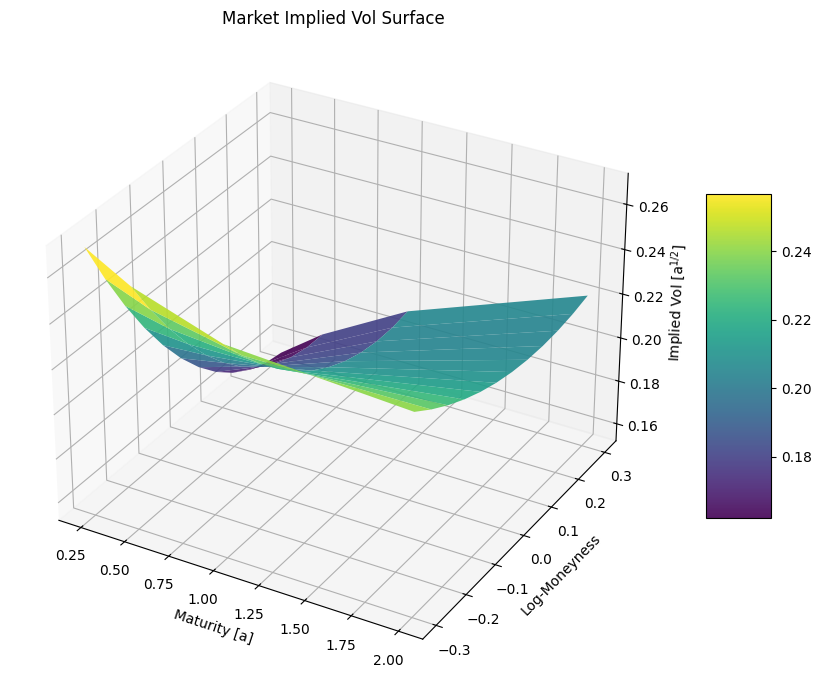

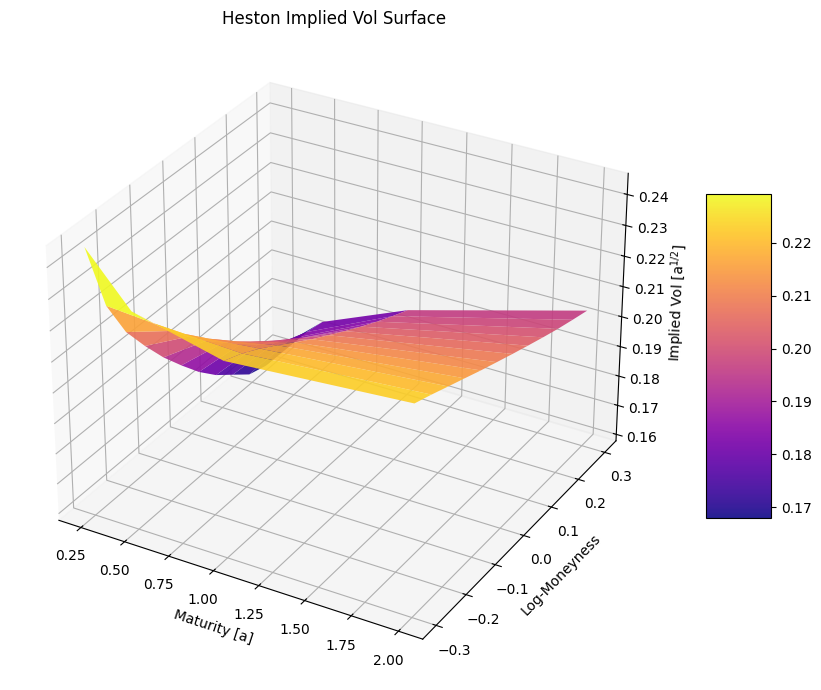

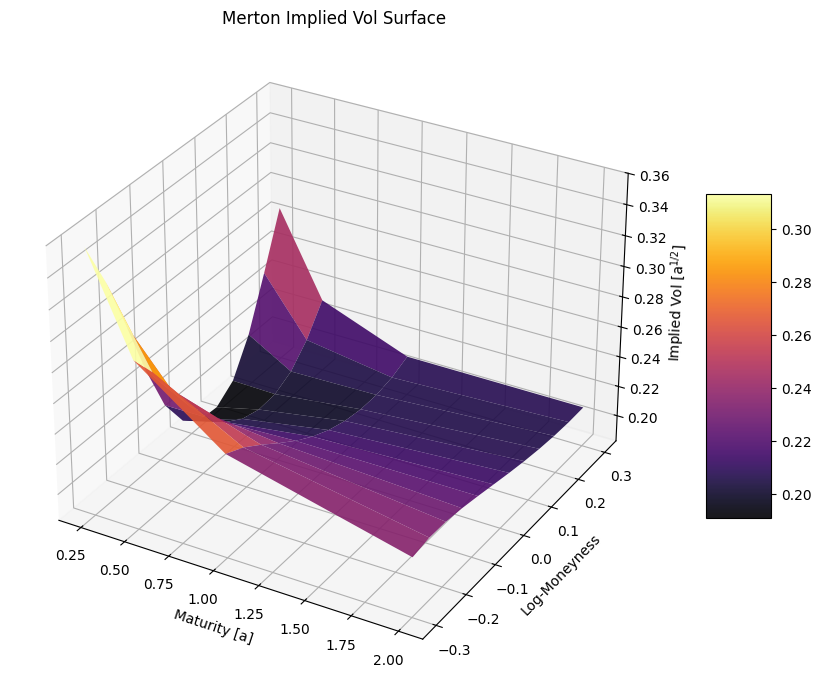

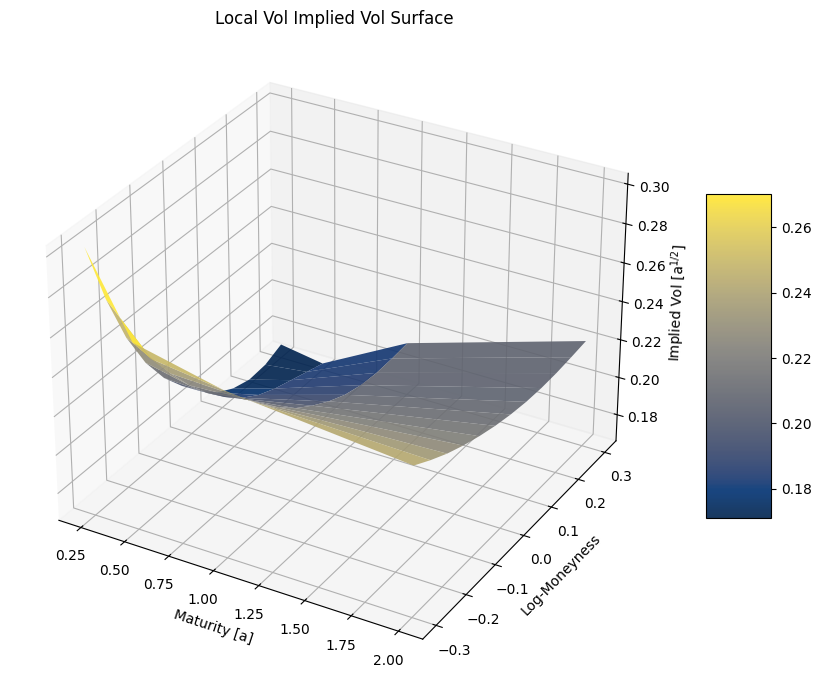

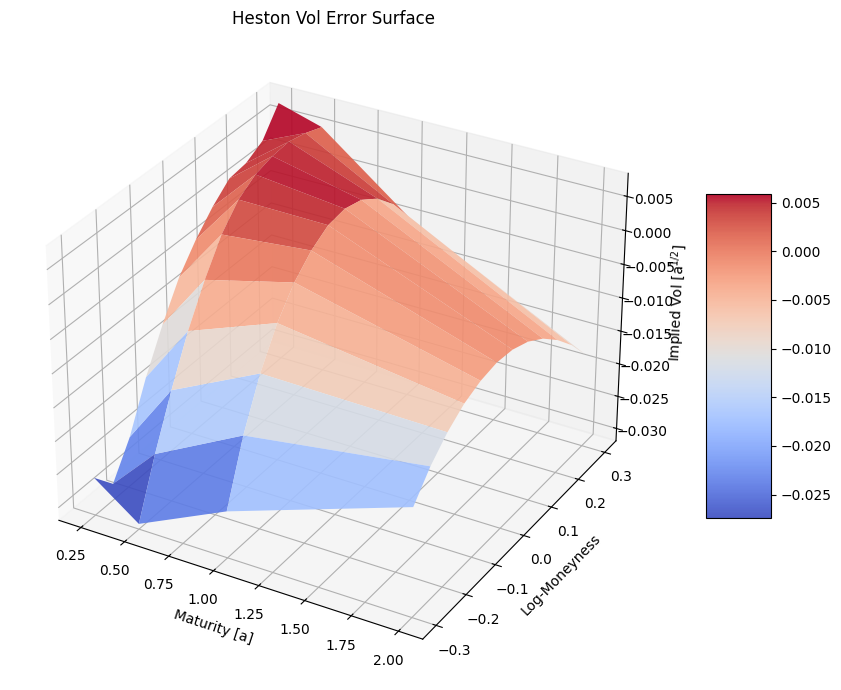

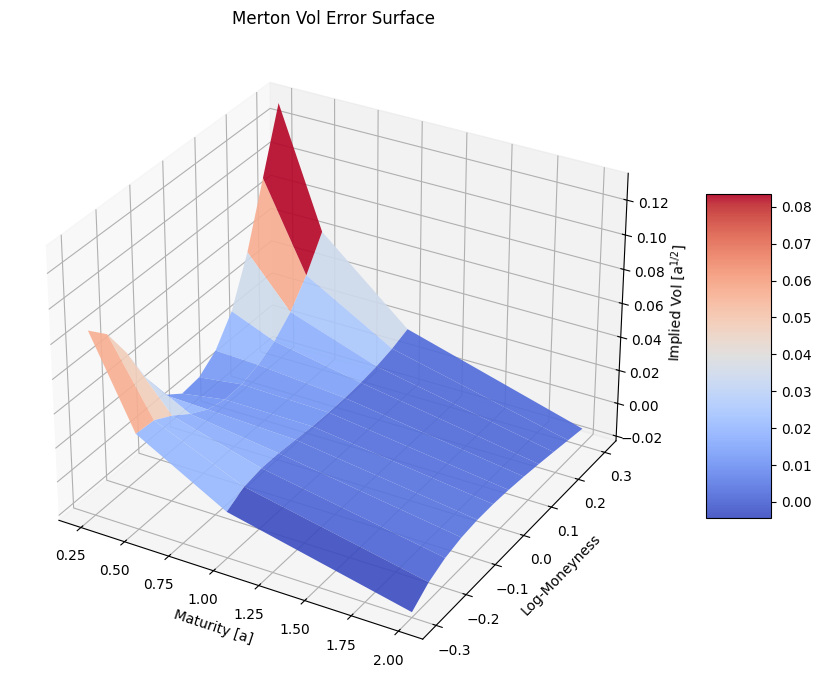

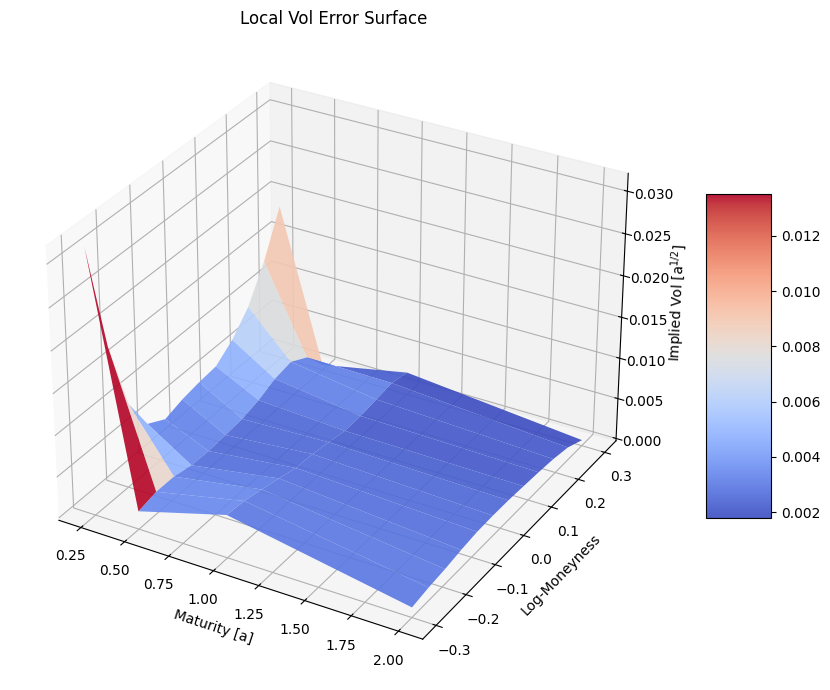

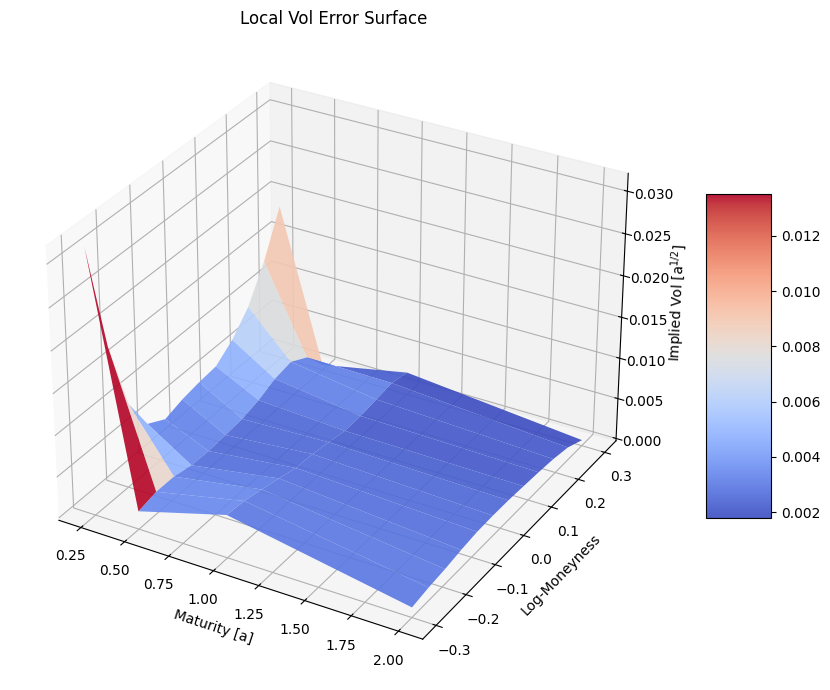

In [14]:
# ============================================================
# GRAFICI 3D - SUPERFICI DI VOLATILITÀ
# ============================================================

print("=" * 60)
print("GENERAZIONE GRAFICI")
print("=" * 60)

T_mesh, K_mesh = np.meshgrid(maturities, k_grid, indexing='ij')

def plot_surface(surface, title, cmap='viridis', figsize=(10, 7)):
    """Crea un plot 3D della superficie di volatilità"""
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(T_mesh, K_mesh, surface, cmap=cmap, alpha=0.9)

    ax.set_xlabel("Maturity [a]")
    ax.set_ylabel("Log-Moneyness")
    ax.set_zlabel("Implied Vol [a$^{1/2}$]")
    ax.set_title(title)

    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    plt.tight_layout()
    plt.show()
    return fig

# Superfici
plot_surface(vol_surface, "Market Implied Vol Surface")
plot_surface(heston_vol_surface, "Heston Implied Vol Surface", 'plasma')
plot_surface(merton_vol_surface, "Merton Implied Vol Surface", 'inferno')
plot_surface(local_vol_surface_model, "Local Vol Implied Vol Surface", 'cividis')

# Error surfaces
plot_surface(heston_vol_surface - vol_surface, "Heston Vol Error Surface", 'coolwarm')
plot_surface(merton_vol_surface - vol_surface, "Merton Vol Error Surface", 'coolwarm')
plot_surface(local_vol_surface_model - vol_surface, "Local Vol Error Surface", 'coolwarm')

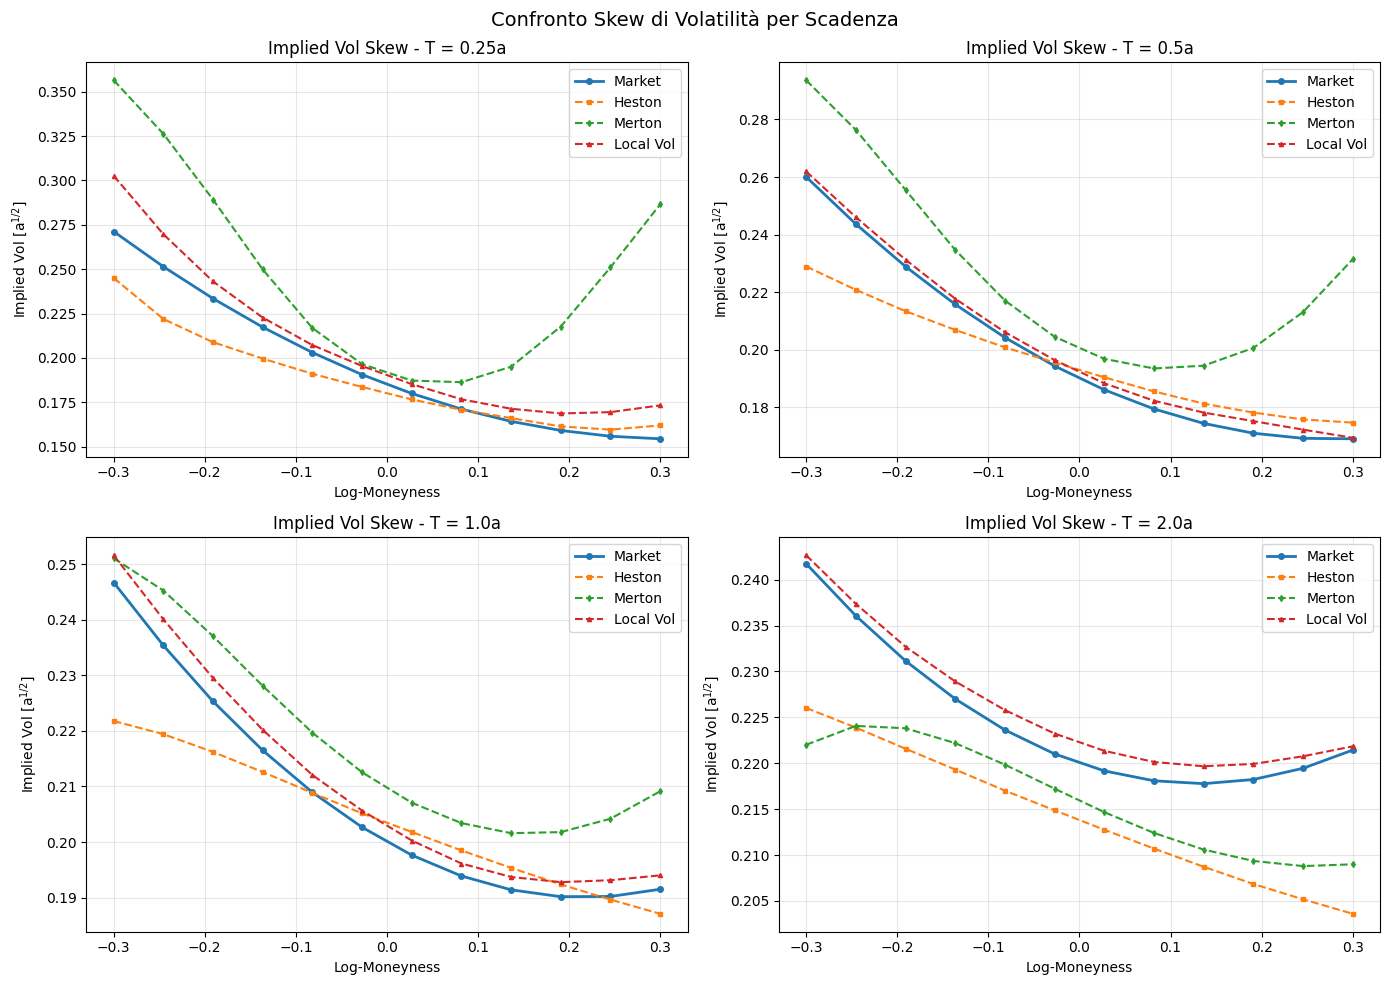

In [15]:
# ============================================================
# GRAFICI 2D - CONFRONTO SKEW PER SCADENZA
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, T in enumerate(maturities):
    axes[idx].plot(k_grid, vol_surface[idx], 'o-', linewidth=2, label="Market", markersize=4)
    axes[idx].plot(k_grid, heston_vol_surface[idx], 's--', label="Heston", markersize=3)
    axes[idx].plot(k_grid, merton_vol_surface[idx], 'd--', label="Merton", markersize=3)
    axes[idx].plot(k_grid, local_vol_surface_model[idx], '^--', label="Local Vol", markersize=3)

    axes[idx].set_title(f"Implied Vol Skew - T = {T}a")
    axes[idx].set_xlabel("Log-Moneyness")
    axes[idx].set_ylabel("Implied Vol [a$^{1/2}$]")
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='best')

plt.suptitle("Confronto Skew di Volatilità per Scadenza", fontsize=14)
plt.tight_layout()
plt.show()

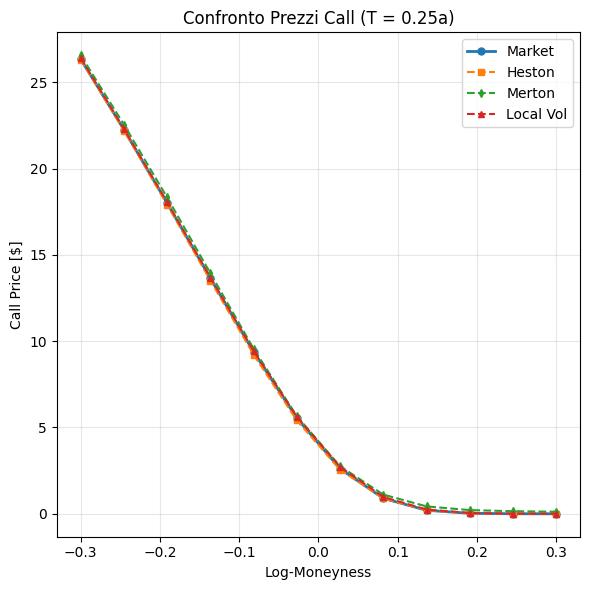

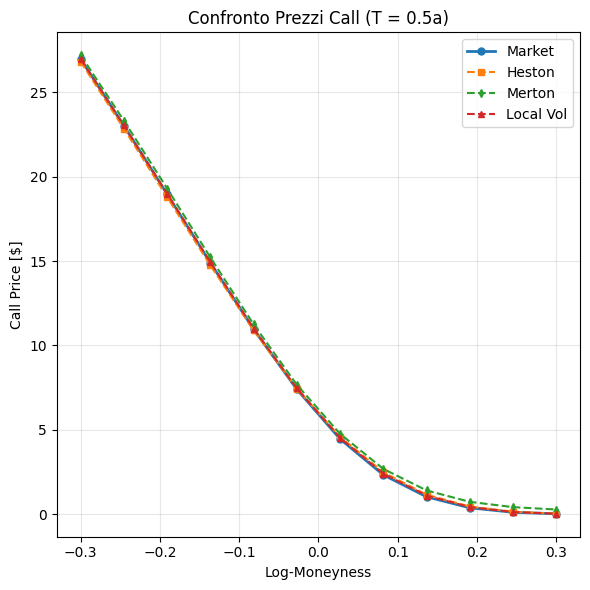

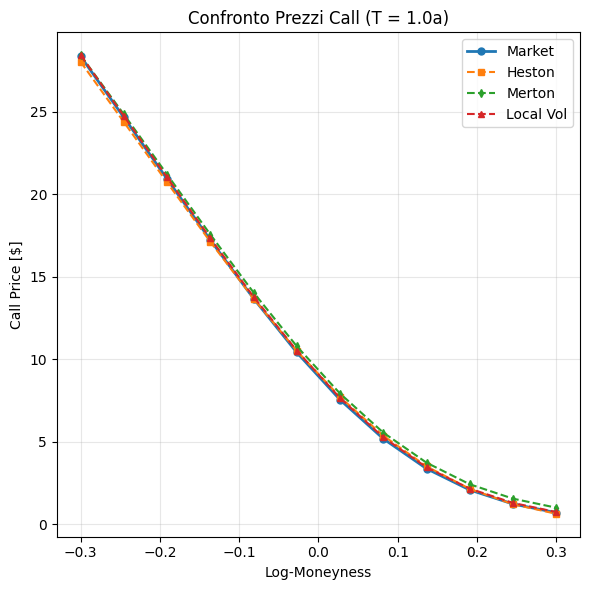

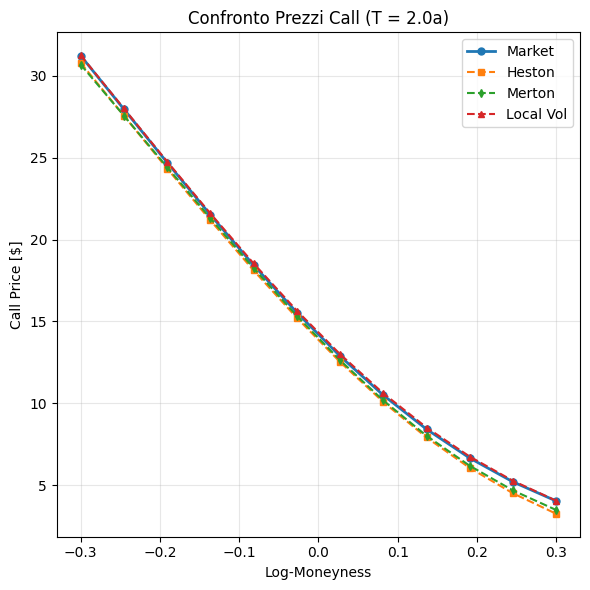

In [16]:
# ============================================================
# GRAFICO CONFRONTO PREZZI CALL (TUTTE LE SCADENZE)
# ============================================================

for i in range(4):

    plt.figure(figsize=(6, 6))
    plt.plot(k_grid, market_prices[i], 'o-', linewidth=2, label="Market", markersize=5)
    plt.plot(k_grid, heston_prices[i], 's--', label="Heston", markersize=4)
    plt.plot(k_grid, merton_prices[i], 'd--', label="Merton", markersize=4)
    plt.plot(k_grid, local_prices[i], '^--', label="Local Vol", markersize=4)

    plt.xlabel("Log-Moneyness")
    plt.ylabel("Call Price [$]")
    plt.title(f"Confronto Prezzi Call (T = {maturities[i]}a)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()




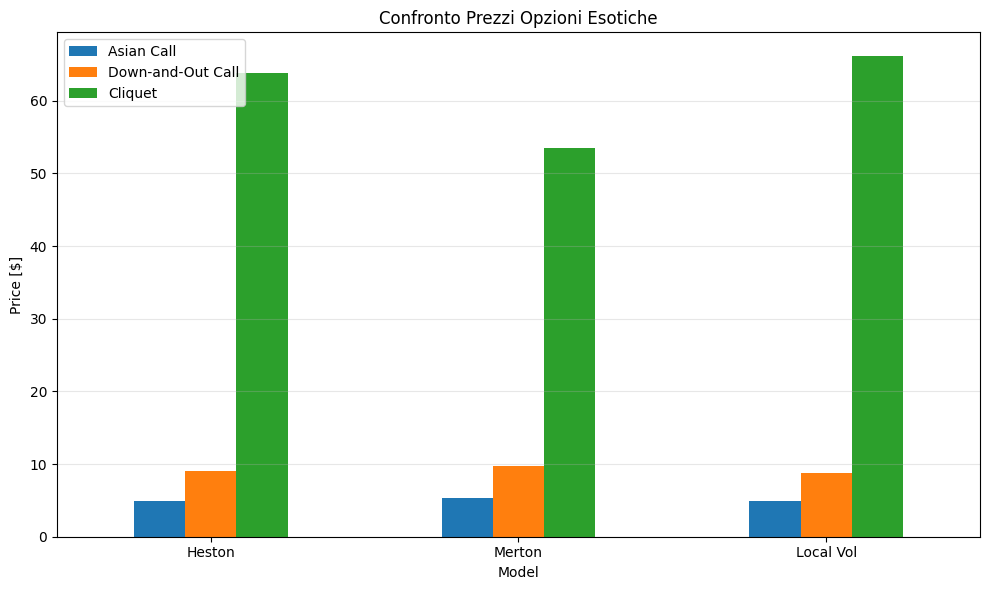

In [17]:
# ============================================================
# BAR CHART OPZIONI ESOTICHE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))
df_exotic[["Asian Call", "Down-and-Out Call", "Cliquet"]].plot(kind="bar", ax=ax)
ax.set_title("Confronto Prezzi Opzioni Esotiche")
ax.set_ylabel("Price [$]")
ax.set_xlabel("Model")
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Indice ATM trovato: 5, k=-0.0273, K=97.31
Prezzo market ATM (T=0.25, K=97.31): 5.5391
  Paths = 1000 (1/8)
  Paths = 5000 (2/8)
  Paths = 10000 (3/8)
  Paths = 25000 (4/8)
  Paths = 50000 (5/8)
  Paths = 100000 (6/8)
  Paths = 250000 (7/8)
  Paths = 500000 (8/8)

DataFrame prezzi (ATM):
    Paths    Heston    Merton  Local Vol
0    1000  5.391154  5.619946   5.139389
1    5000  5.438948  5.657169   5.587102
2   10000  5.428874  5.725065   5.586127
3   25000  5.377491  5.718858   5.582473
4   50000  5.389872  5.712714   5.576754
5  100000  5.383192  5.729890   5.514689
6  250000  5.409185  5.736427   5.599742
7  500000  5.399825  5.722581   5.593687


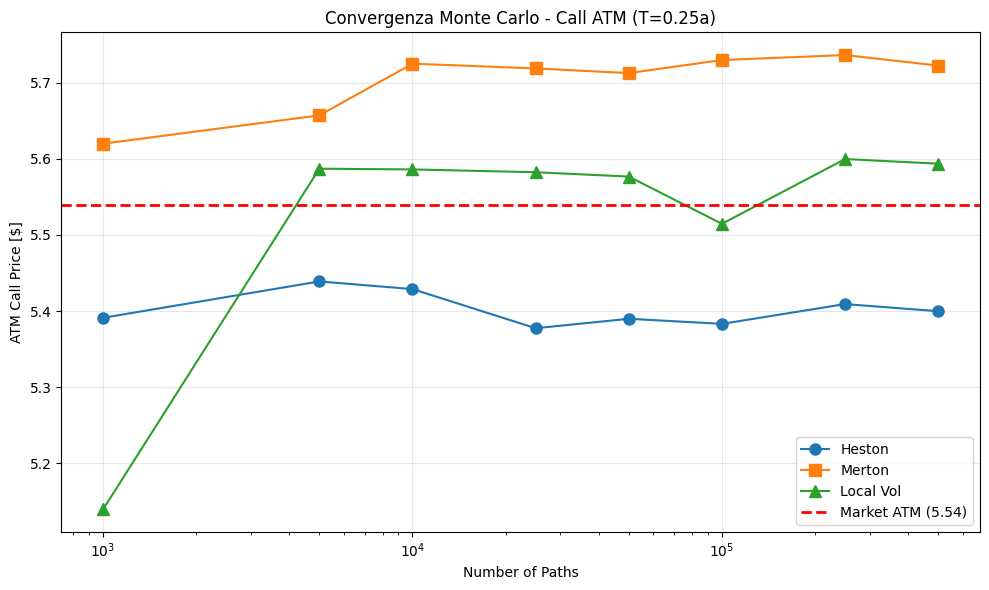


Tempo totale simulazione:
Heston    : 4.6659 s
Merton    : 7.2527 s
Local Vol : 31.4471 s

Indice ATM trovato: 5, k=-0.0273, K=97.31
Prezzo market ATM (T=0.5, K=97.31): 7.4033
  Paths = 1000 (1/8)
  Paths = 5000 (2/8)
  Paths = 10000 (3/8)
  Paths = 25000 (4/8)
  Paths = 50000 (5/8)
  Paths = 100000 (6/8)
  Paths = 250000 (7/8)
  Paths = 500000 (8/8)

DataFrame prezzi (ATM):
    Paths    Heston    Merton  Local Vol
0    1000  7.271677  7.697026   7.616968
1    5000  7.512823  7.737971   7.469978
2   10000  7.430199  7.886276   7.411361
3   25000  7.436707  7.914353   7.378394
4   50000  7.402361  7.934558   7.465282
5  100000  7.402657  7.843265   7.414205
6  250000  7.429420  7.856752   7.500443
7  500000  7.419026  7.868812   7.452277


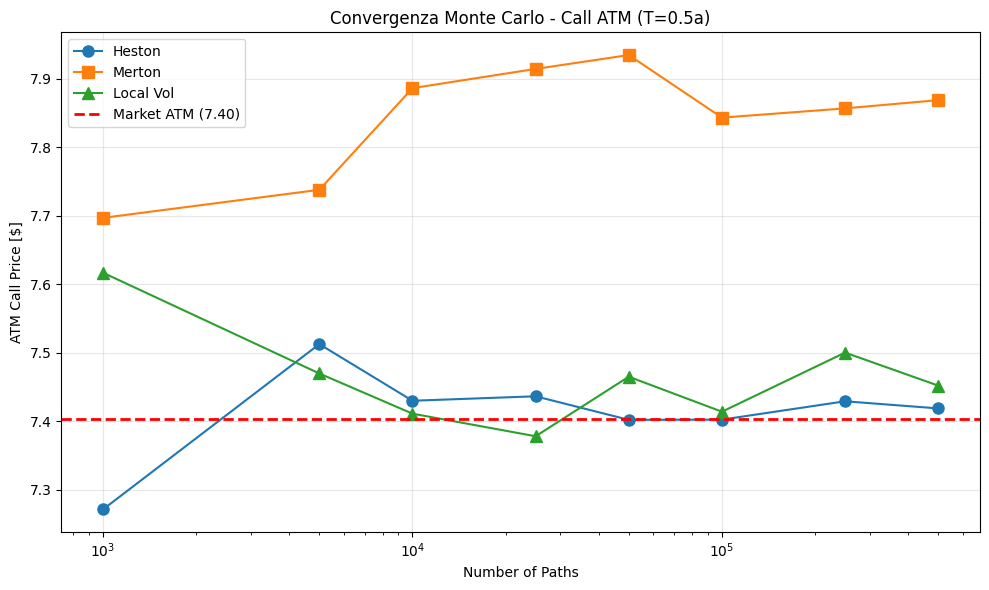


Tempo totale simulazione:
Heston    : 7.5252 s
Merton    : 11.1983 s
Local Vol : 61.4691 s

Indice ATM trovato: 5, k=-0.0273, K=97.31
Prezzo market ATM (T=1.0, K=97.31): 10.4065
  Paths = 1000 (1/8)
  Paths = 5000 (2/8)
  Paths = 10000 (3/8)
  Paths = 25000 (4/8)
  Paths = 50000 (5/8)
  Paths = 100000 (6/8)
  Paths = 250000 (7/8)
  Paths = 500000 (8/8)

DataFrame prezzi (ATM):
    Paths     Heston     Merton  Local Vol
0    1000  10.593551  11.544575  10.797476
1    5000  10.555322  11.606857  10.670972
2   10000  10.684967  11.042081  10.567224
3   25000  10.573914  11.247248  10.501381
4   50000  10.590030  11.316443  10.411964
5  100000  10.625698  11.213707  10.457153
6  250000  10.584341  11.293548  10.395992
7  500000  10.575192  11.211247  10.449205


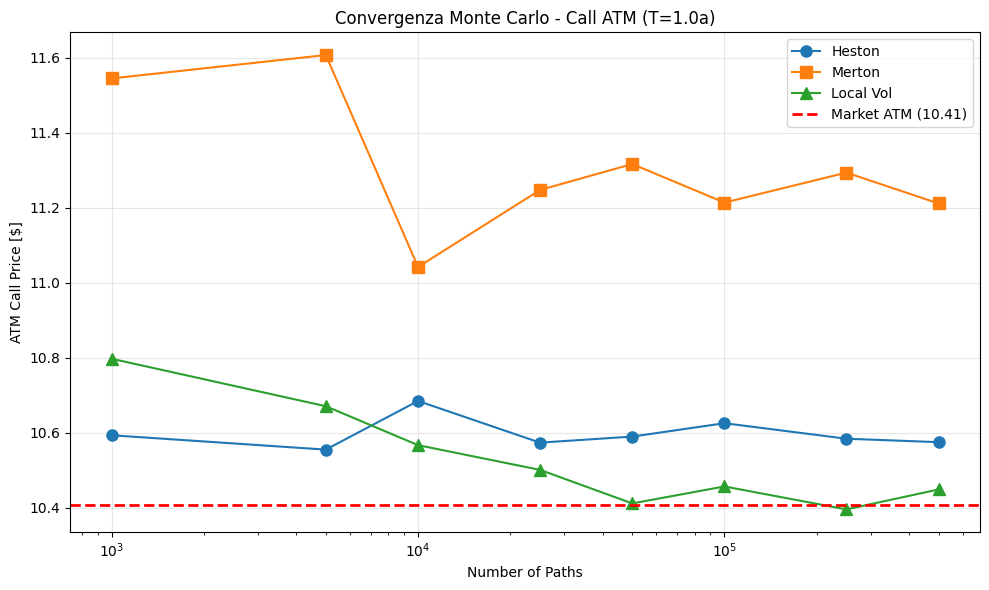


Tempo totale simulazione:
Heston    : 18.0940 s
Merton    : 27.5083 s
Local Vol : 156.6237 s

Indice ATM trovato: 5, k=-0.0273, K=97.31
Prezzo market ATM (T=2.0, K=97.31): 15.5429
  Paths = 1000 (1/8)
  Paths = 5000 (2/8)
  Paths = 10000 (3/8)
  Paths = 25000 (4/8)
  Paths = 50000 (5/8)
  Paths = 100000 (6/8)
  Paths = 250000 (7/8)
  Paths = 500000 (8/8)

DataFrame prezzi (ATM):
    Paths     Heston     Merton  Local Vol
0    1000  14.830499  17.126063  14.413371
1    5000  15.251904  15.873565  15.643878
2   10000  15.363514  16.634242  15.602248
3   25000  15.255940  16.416537  15.790802
4   50000  15.423608  16.421267  15.487992
5  100000  15.277500  16.432852  15.487411
6  250000  15.378080  16.524909  15.507151
7  500000  15.293107  16.474777  15.517526


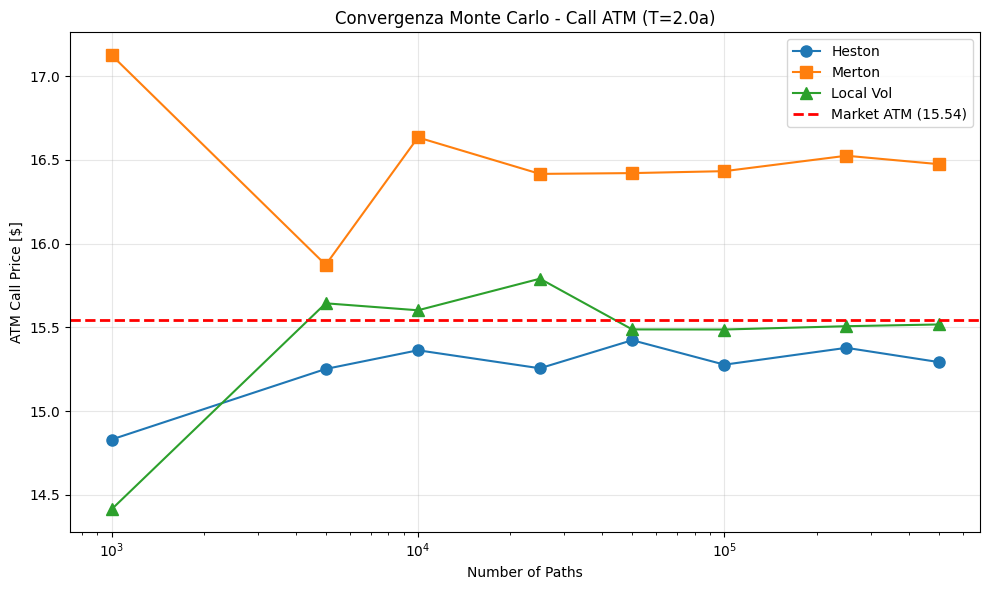


Tempo totale simulazione:
Heston    : 35.1236 s
Merton    : 55.9826 s
Local Vol : 254.1246 s


In [18]:
# ============================================================
# GRAFICO CONVERGENZA MONTE CARLO
# ============================================================


def plot_convergence():
    """Mostra la convergenza dei prezzi Monte Carlo all'aumentare dei path"""

    np.random.seed(42)

    paths_range = [1000, 5000, 10000, 25000, 50000, 100000, 250000, 500000]

    for j in range(len(maturities)):

        T_idx = j

        # TROVA L'INDICE ATM
        atm_idx = np.argmin(np.abs(k_grid - 0))
        print(f"\nIndice ATM trovato: {atm_idx}, k={k_grid[atm_idx]:.4f}, K={S0*np.exp(k_grid[atm_idx]):.2f}")

        T = maturities[T_idx]
        K_atm = S0 * np.exp(k_grid[atm_idx])
        market_price_atm = market_prices[T_idx, atm_idx]

        print(f"Prezzo market ATM (T={T}, K={K_atm:.2f}): {market_price_atm:.4f}")

        heston_prices_conv = []
        merton_prices_conv = []
        local_prices_conv = []

        total_time_heston = 0
        total_time_merton = 0
        total_time_local = 0

        n_step = int(252 * T) #cambia il numero di step a seconda della scadenza

        for i, paths in enumerate(paths_range):

            print(f"  Paths = {paths} ({i+1}/{len(paths_range)})")

            # ---------------- HESTON ----------------
            start = time.perf_counter()

            ST = simulate_heston_terminal(S0, T, heston_params, paths=paths, steps=n_step)
            heston_price = np.exp(-r*T) * np.mean(np.maximum(ST - K_atm, 0))
            heston_prices_conv.append(heston_price)

            total_time_heston += time.perf_counter() - start

            # ---------------- MERTON ----------------
            start = time.perf_counter()

            S_paths = simulate_merton_paths(S0, T, merton_params, paths=paths, steps=n_step)
            ST = S_paths[:, -1]
            merton_price = np.exp(-r*T) * np.mean(np.maximum(ST - K_atm, 0))
            merton_prices_conv.append(merton_price)

            total_time_merton += time.perf_counter() - start

            # ---------------- LOCAL VOL ----------------
            start = time.perf_counter()

            ST = simulate_local_full(S0, T, paths=paths, steps=n_step)[:, -1]
            local_price = np.exp(-r*T) * np.mean(np.maximum(ST - K_atm, 0))
            local_prices_conv.append(local_price)

            total_time_local += time.perf_counter() - start

        # ---------------- DATAFRAME ----------------
        df_prices = pd.DataFrame({
            "Paths": paths_range,
            "Heston": heston_prices_conv,
            "Merton": merton_prices_conv,
            "Local Vol": local_prices_conv
        })

        print("\nDataFrame prezzi (ATM):")
        print(df_prices)

        # ---------------- PLOT ----------------
        plt.figure(figsize=(10,6))

        plt.semilogx(paths_range, heston_prices_conv,'o-',label='Heston',markersize=8)
        plt.semilogx(paths_range, merton_prices_conv,'s-',label='Merton',markersize=8)
        plt.semilogx(paths_range, local_prices_conv,'^-',label='Local Vol',markersize=8)

        plt.axhline(y=market_price_atm,
                    color='r',
                    linestyle='--',
                    linewidth=2,
                    label=f'Market ATM ({market_price_atm:.2f})')

        plt.xlabel('Number of Paths')
        plt.ylabel('ATM Call Price [$]')
        plt.title(f'Convergenza Monte Carlo - Call ATM (T={T}a)')

        plt.legend()
        plt.grid(True,alpha=0.3)
        plt.tight_layout()
        plt.show()

        # ---------------- TEMPI TOTALI ----------------
        print("\nTempo totale simulazione:")
        print(f"Heston    : {total_time_heston:.4f} s")
        print(f"Merton    : {total_time_merton:.4f} s")
        print(f"Local Vol : {total_time_local:.4f} s")


# Chiama la funzione corretta
plot_convergence()


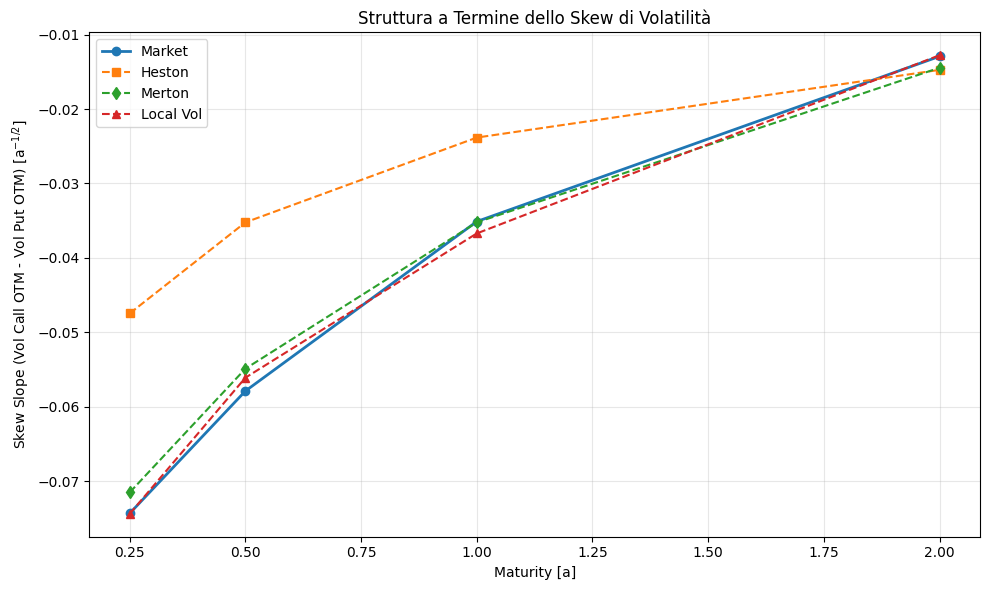

In [19]:
# ============================================================
# ANALISI DELLA STRUTTURA A TERMINE DELLO SKEW
# ============================================================

def analyze_term_structure():
    """Analizza come lo skew evolve con la scadenza"""

    # Calcola slope per ogni scadenza (differenza tra put OTM e call OTM)
    k_otm_put = k_grid[2]  # -0.25 circa
    k_otm_call = k_grid[-3]  # +0.25 circa

    market_slope = []
    heston_slope = []
    merton_slope = []
    local_slope = []

    for i, T in enumerate(maturities):
        market_slope.append(vol_surface[i, -3] - vol_surface[i, 2])
        heston_slope.append(heston_vol_surface[i, -3] - heston_vol_surface[i, 2])
        merton_slope.append(merton_vol_surface[i, -3] - merton_vol_surface[i, 2])
        local_slope.append(local_vol_surface_model[i, -3] - local_vol_surface_model[i, 2])

    plt.figure(figsize=(10, 6))
    plt.plot(maturities, market_slope, 'o-', linewidth=2, label='Market')
    plt.plot(maturities, heston_slope, 's--', label='Heston')
    plt.plot(maturities, merton_slope, 'd--', label='Merton')
    plt.plot(maturities, local_slope, '^--', label='Local Vol')

    plt.xlabel('Maturity [a]')
    plt.ylabel('Skew Slope (Vol Call OTM - Vol Put OTM) [a$^{-1/2}$]')
    plt.title('Struttura a Termine dello Skew di Volatilità')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

analyze_term_structure()